In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from scipy.spatial import cKDTree

In [2]:
class LevelSet2DDistance:
    def __init__(self, grid, f_grid, g_grid, c):
        """
        Parameters
        ----------
        grid : ndarray, shape (nx, ny, 2)
            Domain coordinates corresponding to f_grid/g_grid values.
        f_grid, g_grid : ndarray, shape (nx, ny)
            Scalar fields defined on the domain.
        c : float
            Levelset value (iso-contour) to compare.
        """
        self.grid = grid
        self.f_grid = f_grid
        self.g_grid = g_grid
        self.c = c

        self.contour_f = None
        self.contour_g = None
        self.distance_value = None

    def extract_contours(self):
        """Extract levelset contours for f=c and g=c in domain coordinates."""
        nx, ny = self.f_grid.shape
        xs = self.grid[:, :, 0]
        ys = self.grid[:, :, 1]

        dx = (xs[-1, 0] - xs[0, 0]) / (nx - 1)
        dy = (ys[0, -1] - ys[0, 0]) / (ny - 1)
        origin = np.array([xs[0, 0], ys[0, 0]])

        # Extract contours in index space
        cs_f = measure.find_contours(self.f_grid, level=self.c)
        cs_g = measure.find_contours(self.g_grid, level=self.c)

        # Take the longest contour (handles multiple components)
        cf = max(cs_f, key=len)
        cg = max(cs_g, key=len)

        # Convert to domain coords
        self.contour_f = cf * np.array([dx, dy]) + origin
        self.contour_g = cg * np.array([dx, dy]) + origin

    def compute_distance(self):
        """Compute a simple Riemannian-style distance between the level sets."""
        if self.contour_f is None or self.contour_g is None:
            self.extract_contours()

        # Build KDTree for correspondence
        tree = cKDTree(self.contour_g)
        dists, idxs = tree.query(self.contour_f)

        matched_f = self.contour_f
        matched_g = self.contour_g[idxs]

        # Compute displacement term
        disp = np.linalg.norm(matched_f - matched_g, axis=1)
        E_disp = np.mean(disp ** 2)

        # Compute curvature mismatch (finite differences on curve)
        def curvature(points):
            # approximate curvature for polyline
            pts = np.vstack([points[-1], points, points[0]])
            d1 = np.diff(pts, axis=0)
            d2 = np.diff(d1, axis=0)
            speed = np.linalg.norm(d1[:-1], axis=1) + 1e-12
            cross = d1[:-1, 0] * d2[:, 1] - d1[:-1, 1] * d2[:, 0]
            kappa = cross / (speed ** 3)
            return kappa

        kf = curvature(matched_f)
        kg = curvature(matched_g)
        E_shape = np.mean((kf - kg) ** 2)

        E_total = E_disp + E_shape
        self.distance_value = np.sqrt(E_total)
        return self.distance_value

    def visualize(self, show_correspondence=False):
        """Plot f=c and g=c contours in domain coordinates."""
        if self.contour_f is None or self.contour_g is None:
            self.extract_contours()

        plt.figure(figsize=(6, 6))
        plt.plot(self.contour_f[:, 0], self.contour_f[:, 1], "b-", label="f=c")
        plt.plot(self.contour_g[:, 0], self.contour_g[:, 1], "r-", label="g=c")

        if show_correspondence:
            tree = cKDTree(self.contour_g)
            _, idxs = tree.query(self.contour_f)
            for p, q in zip(self.contour_f[::len(self.contour_f)//50], self.contour_g[idxs][::len(idxs)//50]):
                plt.plot([p[0], q[0]], [p[1], q[1]], "k-", alpha=0.3)

        plt.legend()
        plt.gca().set_aspect("equal")
        plt.title("Levelset contours f=c (blue) and g=c (red)")
        plt.show()

Distance between f and g levelsets: 14.019337923997014


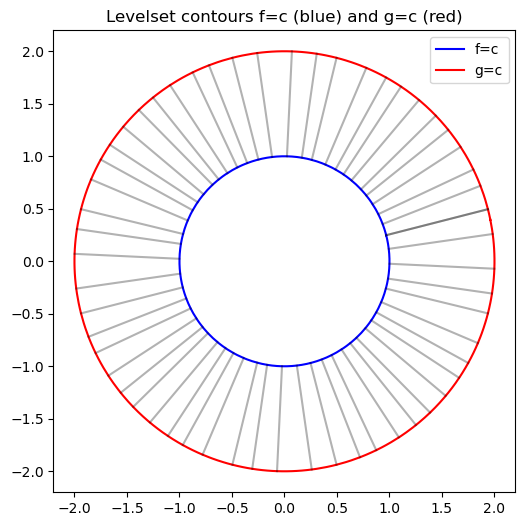

In [3]:
# Domain grid
nx = ny = 128
x = np.linspace(-3, 3, nx)
y = np.linspace(-3, 3, ny)
X, Y = np.meshgrid(x, y, indexing="ij")
grid = np.stack([X, Y], axis=-1)

# Two functions: distance from origin
R = np.sqrt(X**2 + Y**2)
f_grid = R - 1.0   # circle radius 1
g_grid = R - 2.0   # circle radius 2

# Instantiate and compute distance
metric = LevelSet2DDistance(grid, f_grid, g_grid, c=0.0)
dist = metric.compute_distance()
print("Distance between f and g levelsets:", dist)

# Visualize with correspondences
metric.visualize(show_correspondence=True)


Distance between phase map boundaries: 42504.21430099013


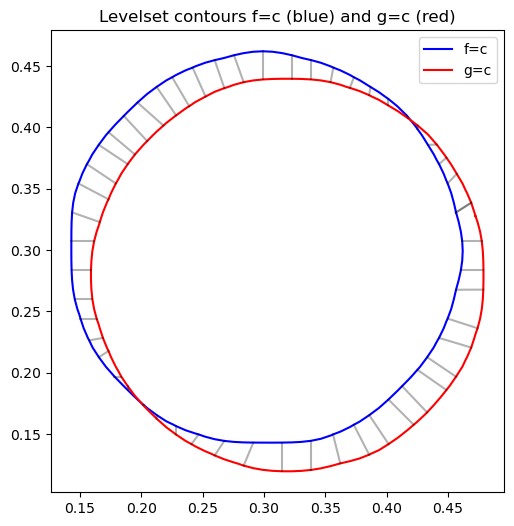

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# --- Create 2D domain ---
nx = ny = 128
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y, indexing="ij")
grid = np.stack([X, Y], axis=-1)

# --- Create synthetic phase map f with 3 regions ---
f_grid = np.zeros((nx, ny))

# Region 1: circle in bottom-left
mask1 = (X-0.3)**2 + (Y-0.3)**2 < 0.15**2
f_grid[mask1] = 0.0

# Region 2: circle in top-right
mask2 = (X-0.7)**2 + (Y-0.7)**2 < 0.15**2
f_grid[mask2] = 0.5

# Region 3: remaining background
mask3 = ~(mask1 | mask2)
f_grid[mask3] = 1.0

# Smooth to get high values at boundaries
f_smooth = gaussian_filter(f_grid, sigma=2)

# --- Create synthetic phase map g (slightly shifted regions) ---
g_grid = np.zeros((nx, ny))

mask1_g = (X-0.32)**2 + (Y-0.28)**2 < 0.15**2
g_grid[mask1_g] = 0.0

mask2_g = (X-0.68)**2 + (Y-0.72)**2 < 0.15**2
g_grid[mask2_g] = 0.5

mask3_g = ~(mask1_g | mask2_g)
g_grid[mask3_g] = 1.0

g_smooth = gaussian_filter(g_grid, sigma=2)

# --- Compute level set distance for boundaries c=0.75 ---
c = 0.75  # near the boundaries between phases
metric = LevelSet2DDistance(grid, f_smooth, g_smooth, c=c)
dist = metric.compute_distance()
print("Distance between phase map boundaries:", dist)

# --- Visualize the level sets / boundaries ---
metric.visualize(show_correspondence=True)
